# Task B — From R to Python: Translating Statistical Analysis
BAFAD Accelerated Research Track · Fall 2026

I translated Questions 2, 3, and 4 from my STAT 270 R assignment into Python using pandas and matplotlib.

In [3]:
!git clone https://github.com/zbryantjones/bafad-research-track.git
%cd bafad-research-track/task-b

Cloning into 'bafad-research-track'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 24 (delta 2), reused 21 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 94.46 KiB | 1.21 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/bafad-research-track/task-b


## Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NAVY = '#021B3A'
BLUE = '#0EA5E9'
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

flights  = pd.read_csv('../data/flights.csv')
airports = pd.read_csv('../data/airports.csv')

print(f'flights:  {flights.shape[0]:,} rows × {flights.shape[1]} columns')
print(f'airports: {airports.shape[0]} rows × {airports.shape[1]} columns')
flights.head(3)

flights:  1,000 rows × 19 columns
airports: 35 rows × 8 columns


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,7,27,669,645,24,1083,1059,45,F9,4502,N772AA,LGA,MKE,254,2294,6,45,2013-07-27 06:00:00
1,2013,7,11,693,715,-22,1334,1356,-9,YV,8275,N414EF,LGA,MCO,401,3254,7,15,2013-07-11 07:00:00
2,2013,3,3,1466,1415,51,2071,2020,58,F9,6396,N348AE,JFK,PHX,365,3196,14,15,2013-03-03 14:00:00


## Question 2 — Frequency Tables and Proportions
### Part A
Number of flights and share of all flights for each carrier, most to least.

In [5]:
counts = flights['carrier'].value_counts()   # already sorted high to low

carrier_counts = pd.DataFrame({
    'carrier': counts.index,
    'n': counts.values
})
carrier_counts['prop'] = carrier_counts['n'] / len(flights)

carrier_counts

,carrier,n,prop
0,F9,74,0.074
1,B6,72,0.072
2,US,71,0.071
3,UA,68,0.068
4,DL,67,0.067
5,MQ,66,0.066
6,VX,64,0.064
7,9E,63,0.063
8,YV,61,0.061
9,EV,61,0.061


**Answer — Which carrier operated the most flights? What was its approximate share?**

In [6]:
top = carrier_counts.iloc[0]
print(f"{top['carrier']} operated the most flights: {int(top['n'])} flights, which is about {top['prop']*100:.1f}% of all flights.")

F9 operated the most flights: 74 flights, which is about 7.4% of all flights.


### Part B
Proportion of flights that arrived late (`arr_delay > 0`) for each carrier, highest to lowest.

In [7]:
def late_rate(x):
    x = x.dropna()          # same as na.rm = TRUE in R
    return (x > 0).mean()

late_arrivals = (
    flights.groupby('carrier')['arr_delay']
           .apply(late_rate)
           .reset_index(name='late_rate')
           .sort_values('late_rate', ascending=False)
           .reset_index(drop=True)
)

late_arrivals

,carrier,late_rate
0,AS,0.735849
1,UA,0.705882
2,YV,0.704918
3,US,0.704225
4,HA,0.689655
5,VX,0.687500
6,DL,0.686567
7,AA,0.672414
8,9E,0.650794
9,EV,0.639344


**Answer — Which carrier had the worst on-time arrival record?**

In [8]:
worst = late_arrivals.iloc[0]
print(f"{worst['carrier']} had the worst on-time record. {worst['late_rate']*100:.1f}% of its flights arrived late.")

AS had the worst on-time record. 73.6% of its flights arrived late.


## Question 3 — Histogram, Density, and Shape
### Part A
Density histogram of `dep_delay` between −60 and 180 minutes, with a KDE curve.

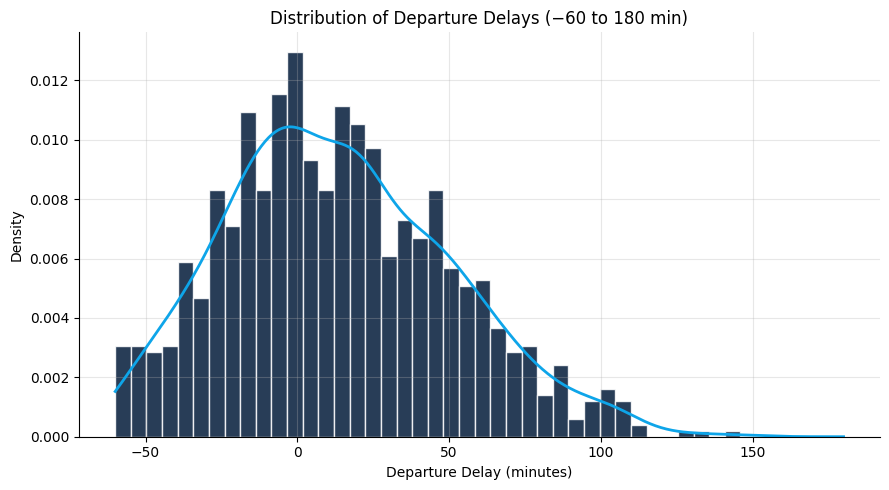

In [9]:
from scipy.stats import gaussian_kde

df_filtered = flights[(flights['dep_delay'] >= -60) & (flights['dep_delay'] <= 180)].copy()

fig, ax = plt.subplots(figsize=(9, 5))

delays = df_filtered['dep_delay'].dropna()

# density histogram
ax.hist(delays, bins=40, density=True, color=NAVY, edgecolor='white', alpha=0.85)

# KDE curve on top
xs  = np.linspace(-60, 180, 400)
kde = gaussian_kde(delays)
ax.plot(xs, kde(xs), color=BLUE, linewidth=2)

ax.grid(alpha=0.3)
ax.set_xlabel('Departure Delay (minutes)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Departure Delays (−60 to 180 min)')
plt.tight_layout()
plt.show()

### Part B
Median and IQR of `dep_delay` (same filtered range), and a description of the distribution.

In [10]:
median_delay = delays.median()
iqr_delay    = delays.quantile(0.75) - delays.quantile(0.25)
print(f'Median departure delay: {median_delay:.1f} min')
print(f'IQR of departure delay: {iqr_delay:.1f} min')

Median departure delay: 11.0 min
IQR of departure delay: 53.8 min


**Answer — Shape, modality, centre, spread:**

In [11]:
from scipy.signal import find_peaks

skew = delays.skew()
if skew > 0.3:
    shape = 'skewed to the right (a longer tail of big delays)'
elif skew < -0.3:
    shape = 'skewed to the left (a longer tail of early departures)'
else:
    shape = 'roughly symmetric'

peaks, _ = find_peaks(kde(xs), prominence=0.05 * kde(xs).max())
n_peaks = len(peaks)
modality = 'unimodal (one main peak)' if n_peaks == 1 else f'multimodal ({n_peaks} peaks)'

print(f'Shape: The distribution is {shape}. The skewness is {skew:.2f}.')
print(f'Modality: It is {modality}.')
print(f'Centre: The median is {median_delay:.1f} minutes, so a typical flight leaves about that many minutes off schedule.')
print(f'Spread: The IQR is {iqr_delay:.1f} minutes, so the middle 50% of flights are spread across that range.')

Shape: The distribution is skewed to the right (a longer tail of big delays). The skewness is 0.40.
Modality: It is unimodal (one main peak).
Centre: The median is 11.0 minutes, so a typical flight leaves about that many minutes off schedule.
Spread: The IQR is 53.8 minutes, so the middle 50% of flights are spread across that range.


## Question 4 — Grouped Summaries by Origin Airport
### Part A
Mean, median, standard deviation, and IQR of `arr_delay` for each origin (EWR, JFK, LGA).

In [12]:
from scipy.stats import iqr as scipy_iqr

origin_summary = (
    flights.groupby('origin')['arr_delay']
           .agg(
               mean_arr='mean',
               median_arr='median',
               sd_arr='std',
               iqr_arr=lambda x: scipy_iqr(x.dropna())
           )
           .reset_index()
)

origin_summary

,origin,mean_arr,median_arr,sd_arr,iqr_arr
0,EWR,16.344411,15.0,43.273994,56.0
1,JFK,20.057637,19.0,43.273791,58.0
2,LGA,15.096273,15.0,42.417081,57.5


### Part B
**Answer:**

In [13]:
s = origin_summary.set_index('origin')

hi = s['mean_arr'].idxmax()
lo = s['mean_arr'].idxmin()
print(f"1. {hi} has the highest mean arrival delay ({s.loc[hi, 'mean_arr']:.1f} min). {lo} has the lowest ({s.loc[lo, 'mean_arr']:.1f} min).")

print("2. Mean vs median:")
for o, r in s.iterrows():
    diff = r['mean_arr'] - r['median_arr']
    if diff > 0.5:
        txt = 'higher than the median, so the delays are skewed to the right (a few big delays pull the mean up)'
    elif diff < -0.5:
        txt = 'lower than the median, so the delays are skewed to the left (a few very early arrivals pull the mean down)'
    else:
        txt = 'about the same as the median, so the delays are roughly symmetric'
    print(f"   - {o}: the mean ({r['mean_arr']:.1f}) is {txt} (median {r['median_arr']:.1f}).")

big = s['sd_arr'].idxmax()
print(f"3. {big} has the greatest spread. Its standard deviation is {s.loc[big, 'sd_arr']:.1f} min, the largest of the three airports.")

1. JFK has the highest mean arrival delay (20.1 min). LGA has the lowest (15.1 min).
2. Mean vs median:
   - EWR: the mean (16.3) is higher than the median, so the delays are skewed to the right (a few big delays pull the mean up) (median 15.0).
   - JFK: the mean (20.1) is higher than the median, so the delays are skewed to the right (a few big delays pull the mean up) (median 19.0).
   - LGA: the mean (15.1) is about the same as the median, so the delays are roughly symmetric (median 15.0).
3. EWR has the greatest spread. Its standard deviation is 43.3 min, the largest of the three airports.


## Reflection (not graded)
The hardest part was remembering that pandas handles missing values differently from R, so I had to drop the NaNs myself to match `na.rm = TRUE`. The most useful thing was that `groupby().agg()` lets me name the output columns, which feels close to `summarise()` in dplyr.